# This notebook generates figures 6B, C, D, E, and G

## Import Packages

In [1]:
import maboss # Package of the Maboss 
import ginsim # Package of the GINsim
import biolqm # Package of biolqm
import openpyxl # Package to save .xlsx files
import pandas as pd # Handle with tables
import matplotlib.pyplot as plt
import numpy as np

## GINsim

### Model import

In [2]:
lrg = ginsim.load('working_data/logical_model_CSC_ewing_sarcoma.zginml')
lqm = ginsim.to_biolqm(lrg)

#Show the model
ginsim.show(lrg)

# Maboss

In [3]:
# Convert GINsim model to maboss
wt_sim = biolqm.to_maboss(lqm)

In [4]:
# Define outputs
wt_sim.network.set_output(('Stem_b1', 'Stem_b2'))

### Figure switch EWS::FLI1/miR-145 [1,0] [0,1]

In [5]:
# Initial state
wt_sim.network.set_istate('EWSR1_FLI1', [1, 0])
wt_sim.network.set_istate('miR_145', [0, 1])
wt_sim.network.set_istate('OCT4', [1, 0])
wt_sim.network.set_istate('SOX2', [1, 0])
wt_sim.network.set_istate('c_Myc', [1, 0])
wt_sim.network.set_istate('Let_7', [0, 1])
wt_sim.network.set_istate('STAT3', [1, 0])
wt_sim.network.set_istate('LIN28', [1, 0])
wt_sim.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):1, (0,1):0, (1,0):0, (1,1):0})


Warning, node Stem_b1 was previously bound to othernodes


In [6]:
#define parameters

wt_sim.update_parameters(discrete_time=0, use_physrandgen=0,
        seed_pseudorandom=100, sample_count=50000,
        max_time=15, time_tick=0.5, thread_count=4,
        statdist_traj_count=100, statdist_cluster_threshold=0.9)

In [7]:
# Run
%time wt_results = wt_sim.run()

CPU times: user 1.16 ms, sys: 1.18 ms, total: 2.34 ms
Wall time: 50.2 ms


In [8]:
# Save results
node_prob = wt_results.get_nodes_probtraj()

In [9]:
node_prob.head()

,Stem_b1,Stem_b2
0.0,0.0,0.0
0.5,0.0,0.0
1.0,0.0,0.0
1.5,0.0,0.0
2.0,0.0,0.0


### Figure switch EWS::FLI1/miR-145 [0.7,0.3] [0.3,0.7]

In [10]:
# Initial state
wt_sim.network.set_istate('EWSR1_FLI1', [0.7, 0.3])
wt_sim.network.set_istate('miR_145', [0.3, 0.7])
wt_sim.network.set_istate('OCT4', [1, 0])
wt_sim.network.set_istate('SOX2', [1, 0])
wt_sim.network.set_istate('c_Myc', [1, 0])
wt_sim.network.set_istate('Let_7', [0, 1])
wt_sim.network.set_istate('STAT3', [1, 0])
wt_sim.network.set_istate('LIN28', [1, 0])
wt_sim.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):1, (0,1):0, (1,0):0, (1,1):0})

Warning, node Stem_b1 was previously bound to othernodes


In [11]:
# Run
%time wt_results = wt_sim.run()

CPU times: user 3.67 ms, sys: 151 μs, total: 3.82 ms
Wall time: 78.5 ms


In [12]:
# Save results
node_prob = wt_results.get_nodes_probtraj()

In [13]:
grafico = node_prob

In [14]:
grafico.head()

,Stem_b1,Stem_b2
0.0,0.009194,0.0
0.5,0.045388,0.0
1.0,0.086244,0.0
1.5,0.121925,0.0
2.0,0.148569,0.0


### Figure switch EWS::FLI1/miR-145 [0.5,0.5] [0.5,0.5]

In [15]:
# Initial state
wt_sim.network.set_istate('EWSR1_FLI1', [0.5, 0.5])
wt_sim.network.set_istate('miR_145', [0.5, 0.5])
wt_sim.network.set_istate('OCT4', [1, 0])
wt_sim.network.set_istate('SOX2', [1, 0])
wt_sim.network.set_istate('c_Myc', [1, 0])
wt_sim.network.set_istate('Let_7', [0, 1])
wt_sim.network.set_istate('STAT3', [1, 0])
wt_sim.network.set_istate('LIN28', [1, 0])
wt_sim.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):1, (0,1):0, (1,0):0, (1,1):0})

Warning, node Stem_b1 was previously bound to othernodes


In [16]:
# Run
%time wt_results = wt_sim.run()

CPU times: user 0 ns, sys: 3.04 ms, total: 3.04 ms
Wall time: 54.9 ms


In [17]:
# Save results
node_prob = wt_results.get_nodes_probtraj()

In [18]:
grafico = pd.concat([grafico, node_prob], axis=1).reindex(grafico.index)

In [19]:
grafico.head()

,Stem_b1,Stem_b2,Stem_b1,Stem_b2
0.0,0.009194,0.0,0.015614,0.0
0.5,0.045388,0.0,0.078811,0.0
1.0,0.086244,0.0,0.153710,0.0
1.5,0.121925,0.0,0.218380,0.0
2.0,0.148569,0.0,0.268451,0.0


### Figure switch EWS::FLI1/miR-145 [0.3,0.7] [0.7,0.3]

In [20]:
# Initial state
wt_sim.network.set_istate('EWSR1_FLI1', [0.3, 0.7])
wt_sim.network.set_istate('miR_145', [0.7, 0.3])
wt_sim.network.set_istate('OCT4', [1, 0])
wt_sim.network.set_istate('SOX2', [1, 0])
wt_sim.network.set_istate('c_Myc', [1, 0])
wt_sim.network.set_istate('Let_7', [0, 1])
wt_sim.network.set_istate('STAT3', [1, 0])
wt_sim.network.set_istate('LIN28', [1, 0])
wt_sim.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):1, (0,1):0, (1,0):0, (1,1):0})

Warning, node Stem_b1 was previously bound to othernodes


In [21]:
# Run
%time wt_results = wt_sim.run()

CPU times: user 663 μs, sys: 2.08 ms, total: 2.75 ms
Wall time: 51.9 ms


In [22]:
# Save results
node_prob = wt_results.get_nodes_probtraj()

In [23]:
grafico = pd.concat([grafico, node_prob], axis=1).reindex(grafico.index)

In [24]:
grafico.head()

,Stem_b1,Stem_b2,Stem_b1,Stem_b2,Stem_b1,Stem_b2
0.0,0.009194,0.0,0.015614,0.0,0.022488,0.0
0.5,0.045388,0.0,0.078811,0.0,0.115902,0.0
1.0,0.086244,0.0,0.153710,0.0,0.228337,0.0
1.5,0.121925,0.0,0.218380,0.0,0.330132,0.0
2.0,0.148569,0.0,0.268451,0.0,0.411108,0.0


### Figure switch EWS::FLI1/miR-145 [0,1] [1,0]

In [25]:
# Initial state
wt_sim.network.set_istate('EWSR1_FLI1', [0, 1])
wt_sim.network.set_istate('miR_145', [1, 0])
wt_sim.network.set_istate('OCT4', [1, 0])
wt_sim.network.set_istate('SOX2', [1, 0])
wt_sim.network.set_istate('c_Myc', [1, 0])
wt_sim.network.set_istate('Let_7', [0, 1])
wt_sim.network.set_istate('STAT3', [1, 0])
wt_sim.network.set_istate('LIN28', [1, 0])
wt_sim.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):1, (0,1):0, (1,0):0, (1,1):0})

Warning, node Stem_b1 was previously bound to othernodes


In [26]:
# Run
%time wt_results = wt_sim.run()

CPU times: user 2.5 ms, sys: 3.22 ms, total: 5.73 ms
Wall time: 66.9 ms


In [27]:
# Save results
node_prob = wt_results.get_nodes_probtraj()

In [28]:
grafico = pd.concat([grafico, node_prob], axis=1).reindex(grafico.index)

In [29]:
grafico.head()

,Stem_b1,Stem_b2,Stem_b1,Stem_b2,Stem_b1,Stem_b2,Stem_b1,Stem_b2
0.0,0.009194,0.0,0.015614,0.0,0.022488,0.0,0.032827,0.0
0.5,0.045388,0.0,0.078811,0.0,0.115902,0.0,0.174992,0.0
1.0,0.086244,0.0,0.153710,0.0,0.228337,0.0,0.355170,0.0
1.5,0.121925,0.0,0.218380,0.0,0.330132,0.0,0.521353,0.0
2.0,0.148569,0.0,0.268451,0.0,0.411108,0.0,0.656489,0.0


In [30]:
# Rename columns
grafico.columns = ['Intermediate 1', 'Complete 1', 'Intermediate 2', 'Complete 2', 'Intermediate 3', 'Complete 3', 'Intermediate 4', 'Complete 4']

In [31]:
grafico.head()

,Intermediate 1,Complete 1,Intermediate 2,Complete 2,Intermediate 3,Complete 3,Intermediate 4,Complete 4
0.0,0.009194,0.0,0.015614,0.0,0.022488,0.0,0.032827,0.0
0.5,0.045388,0.0,0.078811,0.0,0.115902,0.0,0.174992,0.0
1.0,0.086244,0.0,0.153710,0.0,0.228337,0.0,0.355170,0.0
1.5,0.121925,0.0,0.218380,0.0,0.330132,0.0,0.521353,0.0
2.0,0.148569,0.0,0.268451,0.0,0.411108,0.0,0.656489,0.0


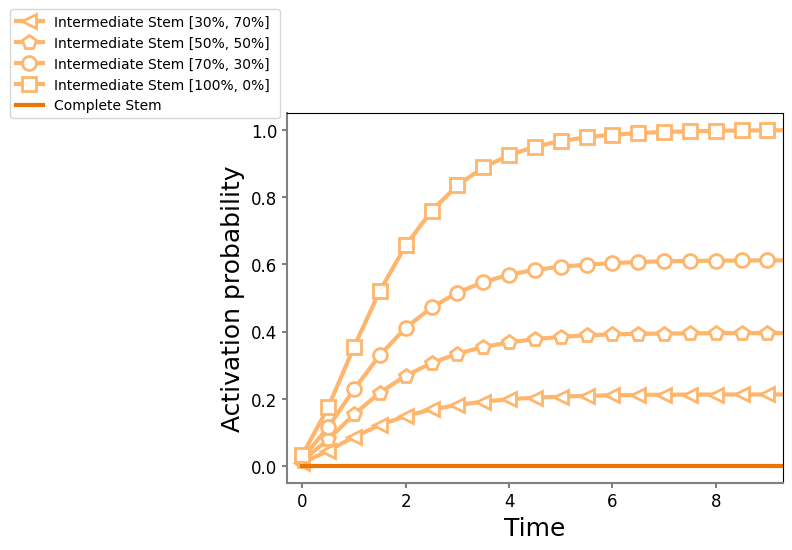

In [53]:
fig, axs = plt.subplots()

axs.set_xlim(-0.3,9.3)

axs.plot(node_prob.index, grafico['Intermediate 1'], linewidth=3, markersize=10, mew= 2,alpha=1, marker='<', color= '#FFB66C', label='Intermediate Stem [30%, 70%] ',  mec = '#FFB66C', mfc = 'white')
axs.plot(node_prob.index, grafico['Intermediate 2'], linewidth=3, markersize=10, mew= 2,alpha=1, marker='p', color= '#FFB66C', label='Intermediate Stem [50%, 50%]',  mec = '#FFB66C', mfc = 'white')
axs.plot(node_prob.index, grafico['Intermediate 3'], linewidth=3, markersize=10, mew= 2,alpha=1, marker='o', color= '#FFB66C', label='Intermediate Stem [70%, 30%]',  mec = '#FFB66C', mfc = 'white')
axs.plot(node_prob.index, grafico['Intermediate 4'], linewidth=3, markersize=10, mew= 2,alpha=1, marker='s',  color= '#FFB66C', label='Intermediate Stem [100%, 0%]',  mec = '#FFB66C', mfc = 'white')
axs.plot(node_prob.index, grafico['Complete 1'], linewidth=3, markersize=10, mew= 2, alpha=1 , color= '#ea7500', label='Complete Stem',  mec = 'black')

axs.spines['top'].set_visible(True)
axs.spines['right'].set_visible(True)
axs.spines['bottom'].set_linewidth(1.5)
axs.spines['left'].set_linewidth(1.5)
axs.spines['bottom'].set_color('gray')
axs.spines['left'].set_color('gray')
axs.tick_params(width=1.5, color='gray')
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)

plt.xlabel("Time", size = 18)
plt.ylabel("Activation probability", size = 18)
plt.legend(bbox_to_anchor=(0, 1.3), loc='upper right', ncol=1)

plt.savefig("/home/daner/Desktop/Github-ewing-stem-5-2026/activation_probability.svg", format="svg", bbox_inches="tight")

### Figures 6C, 6D, 6E, and 6G

In [33]:
# Initial State
wt_sim.network.set_istate('EWSR1_FLI1', [0, 1])
wt_sim.network.set_istate('miR_145', [1, 0])
wt_sim.network.set_istate('OCT4', [0, 1])
wt_sim.network.set_istate('SOX2', [0, 1])
wt_sim.network.set_istate('c_Myc', [1, 0])
wt_sim.network.set_istate('Let_7', [0, 1])
wt_sim.network.set_istate('STAT3', [1, 0])
wt_sim.network.set_istate('LIN28', [0, 1])
wt_sim.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):0, (0,1):0, (1,0):1, (1,1):0})

Warning, node Stem_b1 was previously bound to othernodes


In [34]:
#define parameters

wt_sim.update_parameters(discrete_time=0, use_physrandgen=0,
        seed_pseudorandom=100, sample_count=50000,
        max_time=15, time_tick=0.5, thread_count=4,
        statdist_traj_count=100, statdist_cluster_threshold=0.9)

In [35]:
# Run
%time wt_results = wt_sim.run()

CPU times: user 2.01 ms, sys: 1.05 ms, total: 3.06 ms
Wall time: 65 ms


In [36]:
# Select mutation
mut_sim = wt_sim.copy()
mut_sim.mutate('Let_7', "OFF")
mut_res = mut_sim.run()

In [37]:
# Save results
node_prob = mut_res.get_nodes_probtraj()

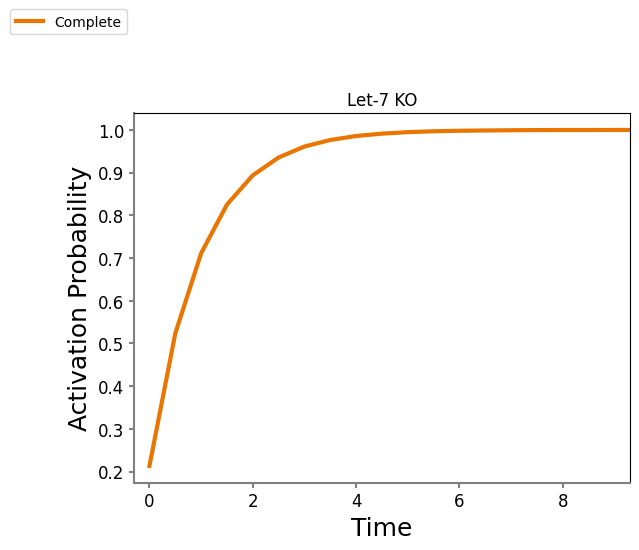

In [38]:
fig, axs = plt.subplots()

axs.set_xlim(-0.3,9.3)

axs.plot(node_prob.index, node_prob['Stem_b2'], linewidth=3, markersize=10, mew= 2, alpha=1 , color= '#ea7500', label='Complete',  mec = 'black')

axs.spines['top'].set_visible(True)
axs.spines['right'].set_visible(True)
axs.spines['bottom'].set_linewidth(1.5)
axs.spines['left'].set_linewidth(1.5)
axs.spines['bottom'].set_color('gray')
axs.spines['left'].set_color('gray')
axs.tick_params(width=1.5, color='gray')
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Time", size = 18)
plt.ylabel("Activation Probability", size = 18)
plt.title('Let-7 KO')
plt.legend(bbox_to_anchor=(0, 1.3), loc='upper right', ncol=1)

In [39]:
# Initial State
wt_sim.network.set_istate('EWSR1_FLI1', [0, 1])
wt_sim.network.set_istate('miR_145', [1, 0])
wt_sim.network.set_istate('OCT4', [0, 1])
wt_sim.network.set_istate('SOX2', [0, 1])
wt_sim.network.set_istate('c_Myc', [1, 0])
wt_sim.network.set_istate('Let_7', [0, 1])
wt_sim.network.set_istate('STAT3', [1, 0])
wt_sim.network.set_istate('LIN28', [0, 1])
wt_sim.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):0, (0,1):0, (1,0):1, (1,1):0})

Warning, node Stem_b1 was previously bound to othernodes


In [40]:
# Run
%time wt_results = wt_sim.run()

CPU times: user 0 ns, sys: 3.11 ms, total: 3.11 ms
Wall time: 60.6 ms


In [41]:
# Select mutation
mut_sim = wt_sim.copy()
mut_sim.mutate('c_Myc', "ON")
mut_res = mut_sim.run()

In [42]:
# Save results
node_prob = mut_res.get_nodes_probtraj()

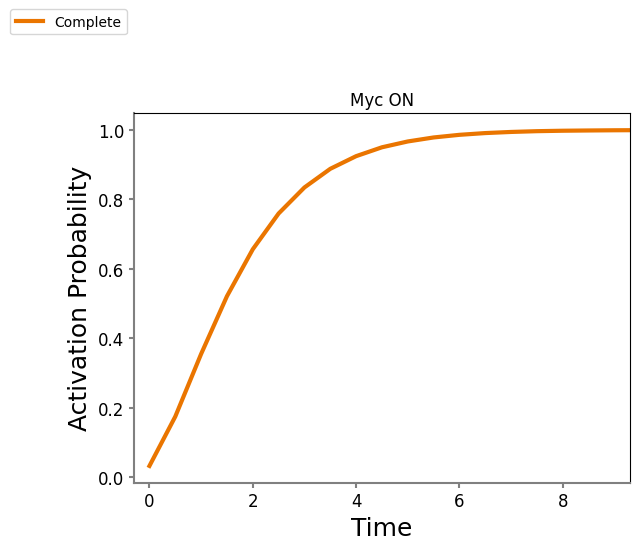

In [43]:
fig, axs = plt.subplots()

axs.set_xlim(-0.3,9.3)

axs.plot(node_prob.index, node_prob['Stem_b2'], linewidth=3, markersize=10, mew= 2, alpha=1 , color= '#ea7500', label='Complete',  mec = 'black')

axs.spines['top'].set_visible(True)
axs.spines['right'].set_visible(True)
axs.spines['bottom'].set_linewidth(1.5)
axs.spines['left'].set_linewidth(1.5)
axs.spines['bottom'].set_color('gray')
axs.spines['left'].set_color('gray')
axs.tick_params(width=1.5, color='gray')
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Time", size = 18)
plt.ylabel("Activation Probability", size = 18)
plt.title('Myc ON')
plt.legend(bbox_to_anchor=(0, 1.3), loc='upper right', ncol=1)

In [44]:
# Select mutation
mut_sim = wt_sim.copy()
mut_sim.mutate('STAT3', "ON")
mut_res = mut_sim.run()

In [45]:
# Save results
node_prob = mut_res.get_nodes_probtraj()

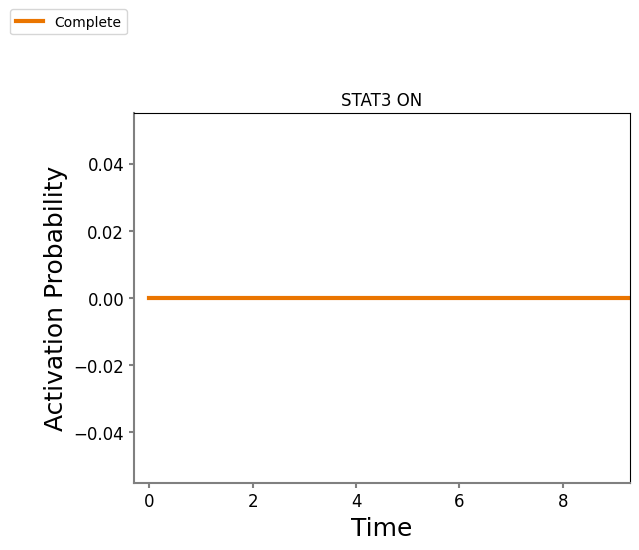

In [46]:
fig, axs = plt.subplots()

axs.set_xlim(-0.3,9.3)

axs.plot(node_prob.index, node_prob['Stem_b2'], linewidth=3, markersize=10, mew= 2, alpha=1 , color= '#ea7500', label='Complete',  mec = 'black')

axs.spines['top'].set_visible(True)
axs.spines['right'].set_visible(True)
axs.spines['bottom'].set_linewidth(1.5)
axs.spines['left'].set_linewidth(1.5)
axs.spines['bottom'].set_color('gray')
axs.spines['left'].set_color('gray')
axs.tick_params(width=1.5, color='gray')
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Time", size = 18)
plt.ylabel("Activation Probability", size = 18)
plt.title('STAT3 ON')
plt.legend(bbox_to_anchor=(0, 1.3), loc='upper right', ncol=1)

In [47]:
# Initial State
wt_sim.network.set_istate('EWSR1_FLI1', [0, 1])
wt_sim.network.set_istate('miR_145', [1, 0])
wt_sim.network.set_istate('OCT4', [0, 1])
wt_sim.network.set_istate('SOX2', [0, 1])
wt_sim.network.set_istate('c_Myc', [0, 1])
wt_sim.network.set_istate('Let_7', [1, 0])
wt_sim.network.set_istate('STAT3', [0, 1])
wt_sim.network.set_istate('LIN28', [0, 1])
wt_sim.network.set_istate(['Stem_b1', 'Stem_b2'],  {(0,0):0, (0,1):1, (1,0):0, (1,1):0})

Warning, node Stem_b1 was previously bound to othernodes


In [48]:
# Run
%time wt_results = wt_sim.run()

CPU times: user 290 μs, sys: 3.19 ms, total: 3.48 ms
Wall time: 52.2 ms


In [49]:
# Select mutation
mut_sim = wt_sim.copy()
mut_sim.mutate('c_Myc', "OFF")
mut_sim.mutate('LIN28', "OFF")
mut_res = mut_sim.run()

In [50]:
# Save results
node_prob = mut_res.get_nodes_probtraj()

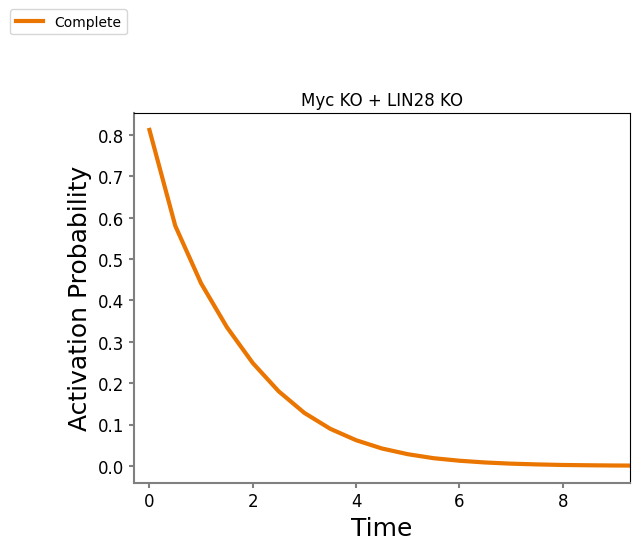

In [51]:
fig, axs = plt.subplots()

axs.set_xlim(-0.3,9.3)

axs.plot(node_prob.index, node_prob['Stem_b2'], linewidth=3, markersize=10, mew= 2, alpha=1 , color= '#ea7500', label='Complete',  mec = 'black')

axs.spines['top'].set_visible(True)
axs.spines['right'].set_visible(True)
axs.spines['bottom'].set_linewidth(1.5)
axs.spines['left'].set_linewidth(1.5)
axs.spines['bottom'].set_color('gray')
axs.spines['left'].set_color('gray')
axs.tick_params(width=1.5, color='gray')
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Time", size = 18)
plt.ylabel("Activation Probability", size = 18)
plt.title('Myc KO + LIN28 KO')
plt.legend(bbox_to_anchor=(0, 1.3), loc='upper right', ncol=1)